In [3]:
%pip install -U roboflow ultralytics


Note: you may need to restart the kernel to use updated packages.


In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6634.3/8062.4 GB disk)


In [6]:
# from roboflow import Roboflow

# rf = Roboflow(api_key="J1mmAuxLk77g4eiOvCmr")
# project = rf.workspace("project-dlcww").project("water_pollution")

# # check versions
# print(project.versions())


In [7]:
from roboflow import Roboflow

rf = Roboflow(api_key="xuAvkLmMP4Hq7FjjopDx")

project = rf.workspace("asad-2t9iu").project("water_pollution-ggvhq")

# check available versions (must NOT be empty now)
print(project.versions())

# use the available version number (usually 1)
version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to water_pollution-1 in yolov8:: 100%|██████████| 7476/7476 [00:01<00:00, 6012.66it/s]


In [8]:
import os

base_path = "/kaggle/working/water_pollution-1"

for folder in ["train/images", "valid/images", "test/images"]:
    path = os.path.join(base_path, folder)
    print(folder, "→", len(os.listdir(path)), "images")


train/images → 3412 images
valid/images → 115 images
test/images → 205 images


# YOLOv8 (Detection)

In [14]:
!yolo task=detect mode=train \
model=yolov8n.pt \
data=/kaggle/working/water_pollution-1/data.yaml \
epochs=50 \
imgsz=640 \
batch=16


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/water_pollution-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

In [15]:
from ultralytics import YOLO

best_model = "/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(best_model)

print("YOLOv8 model loaded successfully")


YOLOv8 model loaded successfully



image 1/1 /kaggle/working/water_pollution-1/test/images/IMG_4017_jpeg.rf.ebfeaa974a1e51166d98cf744ea72032.jpg: 480x640 1 paper, 1 pmb, 5.7ms
Speed: 2.6ms preprocess, 5.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


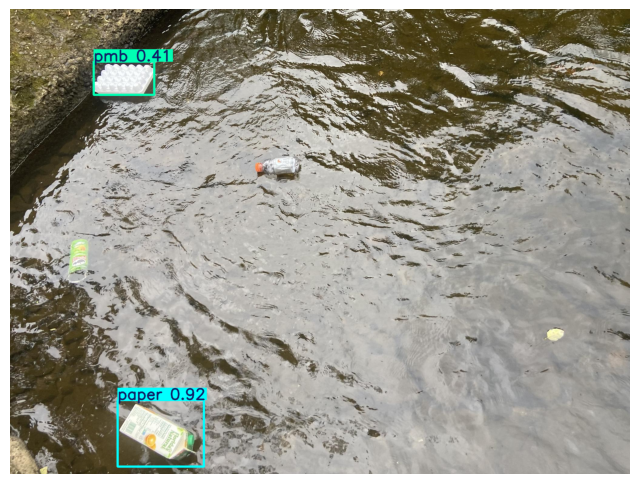

In [17]:
import cv2
import matplotlib.pyplot as plt
import os

test_path = "/kaggle/working/water_pollution-1/test/images"
img_name = os.listdir(test_path)[0]
img_path = os.path.join(test_path, img_name)

results = model.predict(img_path, conf=0.4)

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()


In [18]:
metrics = model.val(
    data="/kaggle/working/water_pollution-1/data.yaml"
)

metrics.results_dict


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1873.5±1301.4 MB/s, size: 94.7 KB)
val: Scanning /kaggle/working/water_pollution-1/valid/labels.cache... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 12.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.7it/s 2.2s0.2ss
                   all        115        146      0.906      0.771      0.876      0.515
        Acid Pollution          8          8          1      0.824      0.955      0.584
Dead Animals Pollution          7          8      0.954      0.375      0.591      0.249
Eutrophication Pollution          9          9      0.771      0.778      0.827      0.585
                  Fish         11         12          1      0.618      0.834      0.513
         Oil Pollution         10         10      0.932        0.8      0.883       0.48
     Pl

{'metrics/precision(B)': 0.9057313904130113,
 'metrics/recall(B)': 0.7714780364869389,
 'metrics/mAP50(B)': 0.8763921051137733,
 'metrics/mAP50-95(B)': 0.5145032761252568,
 'fitness': 0.5145032761252568}

In [19]:
import shutil

shutil.make_archive(
    "/kaggle/working/yolov8_results",
    'zip',
    "/kaggle/working/runs"
)

print("ZIP file created successfully")


ZIP file created successfully


# YOLOv9 (Detection)

In [2]:
%pip install -U roboflow ultralytics

import ultralytics
ultralytics.checks()


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6634.3/8062.4 GB disk)


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="xuAvkLmMP4Hq7FjjopDx")  # Your API key
project = rf.workspace("asad-2t9iu").project("water_pollution-ggvhq")
version = project.version(1)

dataset = version.download("yolov8")  # YOLOv9 still uses same format

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to water_pollution-1 in yolov8:: 100%|██████████| 7476/7476 [00:01<00:00, 6008.48it/s]


Train dataset has 3412 images.


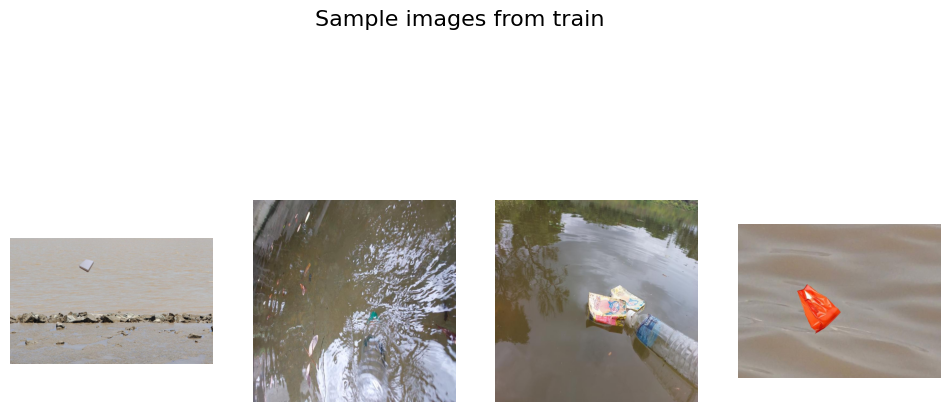

Valid dataset has 115 images.


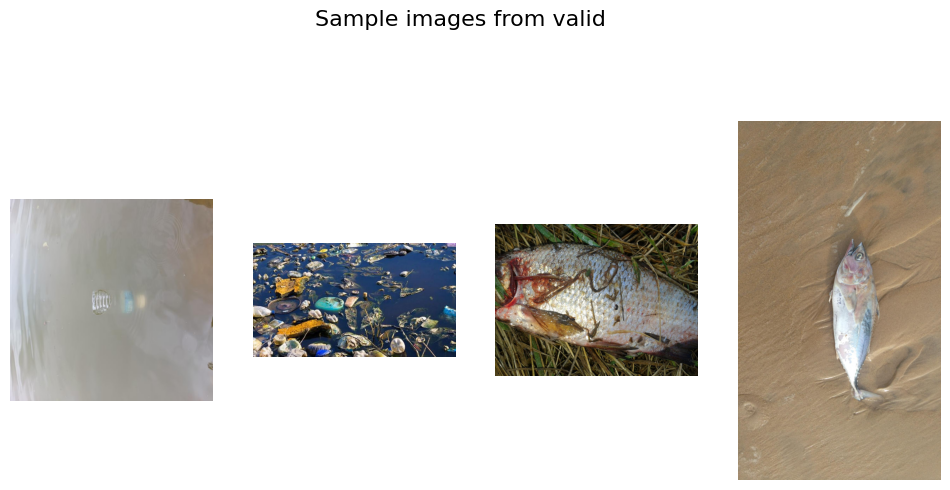

Test dataset has 205 images.


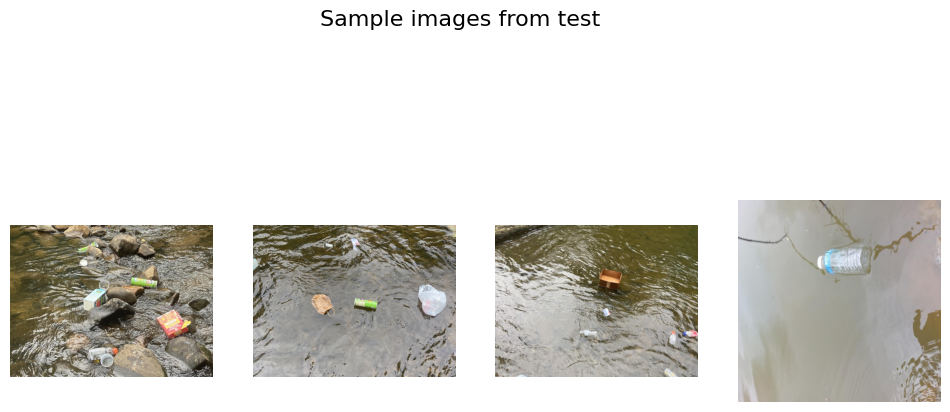

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_paths = {
    'train': '/kaggle/working/water_pollution-1/train/images',
    'valid': '/kaggle/working/water_pollution-1/valid/images',
    'test': '/kaggle/working/water_pollution-1/test/images'
}

for dataset_name, image_folder in dataset_paths.items():
    images = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]
    print(f"{dataset_name.capitalize()} dataset has {len(images)} images.")
    
    # Show first 4 images
    plt.figure(figsize=(12,6))
    for i, img_file in enumerate(images[:4]):
        img = Image.open(os.path.join(image_folder, img_file))
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Sample images from {dataset_name}', fontsize=16)
    plt.show()


In [11]:
from ultralytics import YOLO

model = YOLO("yolov9s.pt")  # or yolov9m.pt, yolov10s.pt, etc.

results = model.train(
    data="/kaggle/working/water_pollution-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov9s_water_pollution",  # optional: nice run folder name
    # add any other args you want, e.g. patience=20, optimizer='AdamW', etc.
)

print("Training finished!")

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/water_pollution-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9s_water_pollution, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [12]:
best_model = "/kaggle/working/runs/detect/yolov9s_water_pollution/weights/best.pt"
model = YOLO(best_model)

In [13]:
from ultralytics import YOLO
import shutil
import os

# ────────────────────────────────────────────────
# After training is done (replace with your actual experiment name)
experiment_name = "yolov9s_water_pollution"   # ← change this to match your `name=...` arg
# or if you didn't set name, it might be "train", "train2", etc. — check /kaggle/working/runs/detect/

weights_dir = f"/kaggle/working/runs/detect/{experiment_name}/weights"
best_src  = os.path.join(weights_dir, "best.pt")
last_src  = os.path.join(weights_dir, "last.pt")

# Where you want to save the final copies (easy to find/download)
output_dir = "/kaggle/working/saved_models"
os.makedirs(output_dir, exist_ok=True)

best_dest = os.path.join(output_dir, f"yolov9s_water-pollution_best.pt")
last_dest = os.path.join(output_dir, f"yolov9s_water-pollution_last.pt")

# Copy best & last to a clean location
if os.path.exists(best_src):
    shutil.copy(best_src, best_dest)
    print(f"Best model saved/copied to: {best_dest}")
else:
    print("best.pt not found — training might have issues!")

if os.path.exists(last_src):
    shutil.copy(last_src, last_dest)
    print(f"Last model saved/copied to: {last_dest}")
else:
    print("last.pt not found (rare)")

# Optional: also zip the entire runs folder like you did before
shutil.make_archive(
    "/kaggle/working/yolov9_results",
    'zip',
    "/kaggle/working/runs/detect"   # or just your experiment folder if you want smaller zip
)
print("ZIP of runs created!")

Best model saved/copied to: /kaggle/working/saved_models/yolov9s_water-pollution_best.pt
Last model saved/copied to: /kaggle/working/saved_models/yolov9s_water-pollution_last.pt
ZIP of runs created!


YOLOv9 custom model loaded successfully!

image 1/1 /kaggle/working/water_pollution-1/test/images/IMG_3886_jpeg.rf.75ba824d1b341e8dd5ea7ffb3bd23364.jpg: 480x640 (no detections), 65.5ms
Speed: 2.7ms preprocess, 65.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


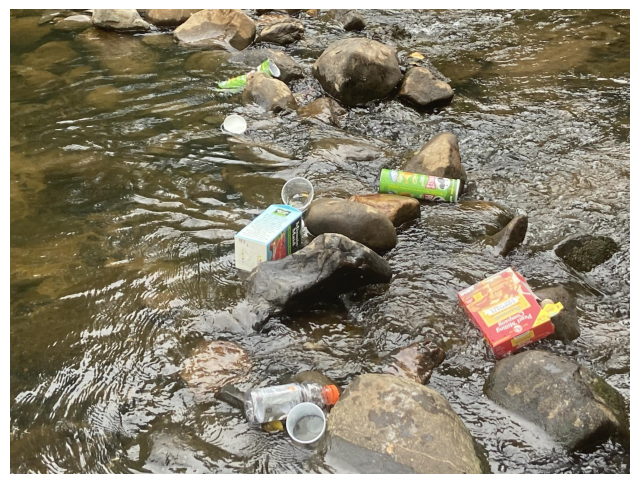

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 913.6±553.2 MB/s, size: 35.6 KB)
val: Scanning /kaggle/working/water_pollution-1/valid/labels.cache... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 43.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.1it/s 2.6s0.2ss
                   all        115        146      0.853      0.814       0.89      0.571
        Acid Pollution          8          8      0.864        0.8      0.954      0.655
Dead Animals Pollution          7          8      0.745      0.625      0.663      0.327
Eutrophication Pollution          9          9      0.771      0.778      0.867      0.744
                  Fish         11         12      0.869       0.75      0.828      0.595
         Oil Pollution         10         10       0.76      0.637      0.914      0.533
     Plas

In [14]:
# Load your saved best model
best_model_path = "/kaggle/working/saved_models/yolov9s_water-pollution_best.pt"
model = YOLO(best_model_path)
print("YOLOv9 custom model loaded successfully!")

# ── Your prediction code ──
import cv2
import matplotlib.pyplot as plt
import os

test_path = "/kaggle/working/water_pollution-1/test/images"
img_name = os.listdir(test_path)[0]
img_path = os.path.join(test_path, img_name)

results = model.predict(img_path, conf=0.4)
img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

# Validation
metrics = model.val(data="/kaggle/working/water_pollution-1/data.yaml")
print(metrics.results_dict)

In [15]:
import yaml
import os

# Adjust if your dataset folder name is slightly different
data_yaml_path = "/kaggle/working/water_pollution-1/data.yaml"

if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    
    class_names = data.get('names', [])
    num_classes = data.get('nc', len(class_names))
    
    print(f"Number of classes (nc): {num_classes}")
    print("Class names in order:")
    for i, name in enumerate(class_names):
        print(f"  {i}: {name}")
else:
    print(f"File not found: {data_yaml_path}")
    print("Check your dataset folder with: !ls /kaggle/working/water_pollution-*")

Number of classes (nc): 20
Class names in order:
  0: ---
  1: Acid Pollution
  2: Dead Animals Pollution
  3: Eutrophication Pollution
  4: Fish
  5: Oil Pollution
  6: Plastic Pollution
  7: bottle
  8: cardboard
  9: glass
  10: leaf
  11: metal
  12: paper
  13: plastic
  14: pmb
  15: sld
  16: slh
  17: trash_plastic
  18: water
  19: waterbottle


# YOLOv10 (Detection)

In [9]:
!yolo task=detect mode=train \
model=yolov10n.pt \
data=/kaggle/working/water_pollution-1/data.yaml \
epochs=50 \
imgsz=640 \
batch=16


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/water_pollution-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

In [10]:
from ultralytics import YOLO

best_model = "/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(best_model)

print("YOLOv10 model loaded successfully")

YOLOv10 model loaded successfully



image 1/1 /kaggle/working/water_pollution-1/test/images/20220202_130319_jpg.rf.35607b67245f972338441a3b264758f5.jpg: 480x640 2 trash_plastics, 48.4ms
Speed: 3.4ms preprocess, 48.4ms inference, 20.6ms postprocess per image at shape (1, 3, 480, 640)


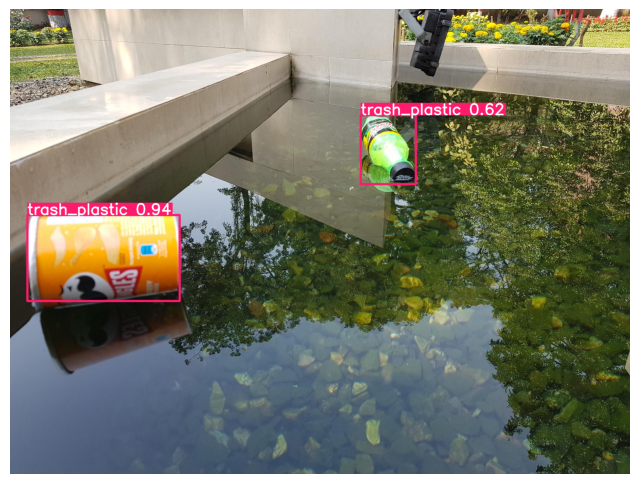

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

test_path = "/kaggle/working/water_pollution-1/test/images"
img_name = os.listdir(test_path)[0]
img_path = os.path.join(test_path, img_name)

results = model.predict(img_path, conf=0.4)

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()


In [12]:
metrics = model.val(
    data="/kaggle/working/water_pollution-1/data.yaml"
)

metrics.results_dict


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1392.1±1098.5 MB/s, size: 88.9 KB)
val: Scanning /kaggle/working/water_pollution-1/valid/labels.cache... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 15.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.9it/s 2.1s0.4ss
                   all        115        146      0.779      0.816      0.862      0.506
        Acid Pollution          8          8      0.744       0.75      0.841      0.587
Dead Animals Pollution          7          8      0.753      0.625      0.724      0.357
Eutrophication Pollution          9          9       0.88      0.819      0.939      0.603
                  Fish         11         12      0.919      0.667      0.859      0.488
         Oil Pollution         10         10      0.786      0.736      0.928      0.475
     Pl

{'metrics/precision(B)': 0.7794598747064078,
 'metrics/recall(B)': 0.8161693202990908,
 'metrics/mAP50(B)': 0.8618264300382625,
 'metrics/mAP50-95(B)': 0.5064624104965563,
 'fitness': 0.5064624104965563}

In [13]:
import shutil

shutil.make_archive(
    "/kaggle/working/yolov10_results",
    'zip',
    "/kaggle/working/runs"
)

print("YOLOv10 ZIP created successfully")

YOLOv10 ZIP created successfully
